In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv("coffee_shop_revenue.csv")

print(f"Kích thước tập dữ liệu ban đầu: {df.shape}")
df.head()

Kích thước tập dữ liệu ban đầu: (2000, 7)


,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [5]:
# Kiểm tra thông tin cấu trúc và kiểu dữ liệu của các cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [ ]:
# Đếm số lượng giá trị NaN trong từng cột
missing_values = df.isnull().sum()
print("Số lượng missing values trong mỗi cột:\n", missing_values)

Số lượng missing values trong mỗi cột:
 Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


In [7]:
# Kiểm tra số lượng dòng trùng lặp
duplicates_count = df.duplicated().sum()
print(f"Số dòng dữ liệu bị trùng lặp: {duplicates_count}")

# Xóa các dòng trùng lặp (nếu có) và cập nhật lại DataFrame
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Kích thước dữ liệu sau khi xóa trùng lặp: {df.shape}")

Số dòng dữ liệu bị trùng lặp: 0


In [8]:
# Chuyển tên cột thành chữ thường
df.columns = df.columns.str.lower()

print("Tên cột sau khi chuẩn hóa:")
print(df.columns)

Tên cột sau khi chuẩn hóa:
Index(['number_of_customers_per_day', 'average_order_value',
       'operating_hours_per_day', 'number_of_employees',
       'marketing_spend_per_day', 'location_foot_traffic', 'daily_revenue'],
      dtype='object')


In [12]:
#. Lưu toàn bộ tập dữ liệu ra file CSV mới
df.to_csv("coffee_shop_revenue_cleaned.csv", index=False)
print(f"Đã lưu toàn bộ dữ liệu vào file: coffee_shop_revenue_cleaned.csv")
print(f"Kích thước tập dữ liệu: {df.shape}")

Đã lưu toàn bộ dữ liệu vào file: coffee_shop_revenue_cleaned.csv
Kích thước tập dữ liệu: (2000, 7)


In [13]:
# Thiết lập chung cho đồ thị
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Thống kê mô tả
print("--- THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU ---")
display(df.describe().round(2))

--- THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU ---


,number_of_customers_per_day,average_order_value,operating_hours_per_day,number_of_employees,marketing_spend_per_day,location_foot_traffic,daily_revenue
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,274.30,6.26,11.67,7.95,252.61,534.89,1917.33
std,129.44,2.18,3.44,3.74,141.14,271.66,976.20
min,50.00,2.50,6.00,2.00,10.12,50.00,-58.95
25%,164.00,4.41,9.00,5.00,130.12,302.00,1140.08
50%,275.00,6.30,12.00,8.00,251.00,540.00,1770.78
75%,386.00,8.12,15.00,11.00,375.35,767.00,2530.46
max,499.00,10.00,17.00,14.00,499.74,999.00,5114.60


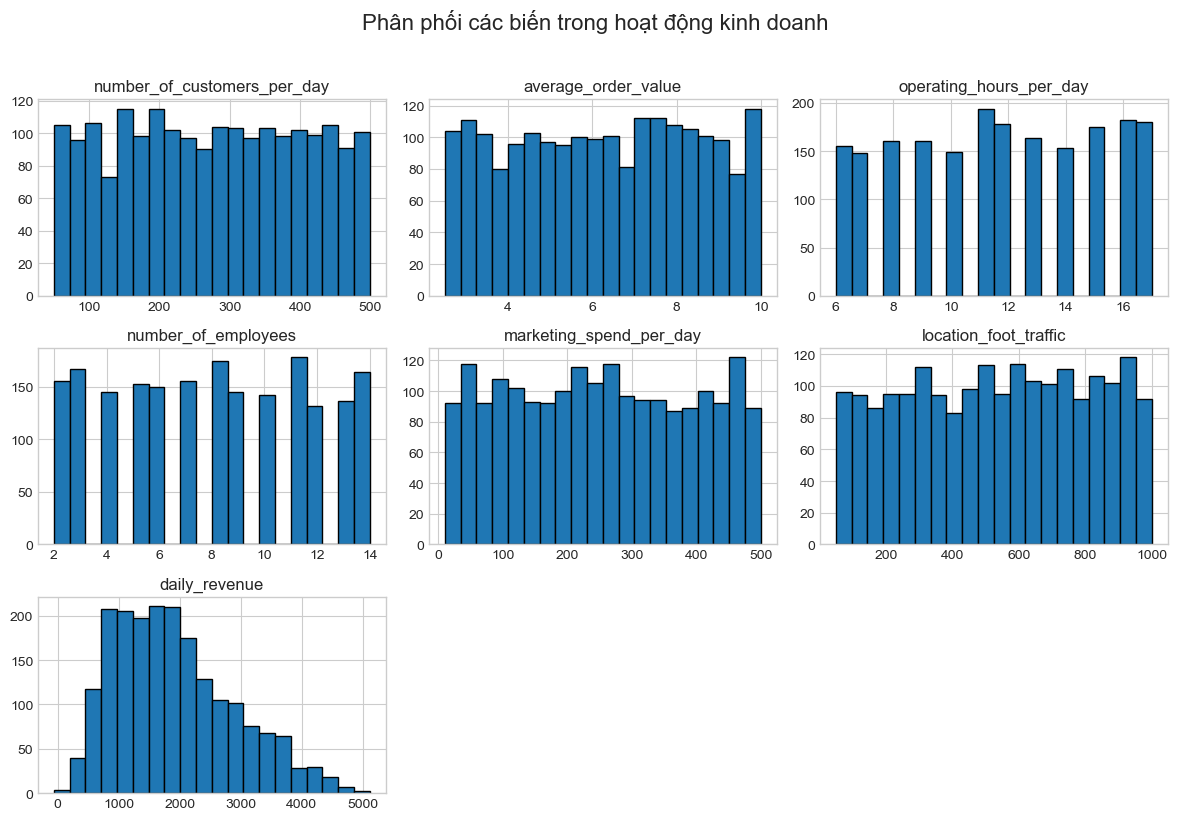

In [14]:
# 2. Histogram (Phân phối của các biến)
df.hist(bins=20, figsize=(12, 8), color='#1f77b4', edgecolor='black')
plt.suptitle('Phân phối các biến trong hoạt động kinh doanh', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Từ Hình 1  có thể thấy:
- Phân bố của biến doanh thu không tuân theo dạng chuẩn mà có xu hướng lệch phải rõ rệt (right-skewed). 
- Tần suất doanh thu cao nhất tập trung trong khoảng từ 1.000 đến 2.000, cho thấy đây là mức vận hành phổ biến và ổn định của quán. 
- Tuy nhiên, sự xuất hiện của các dải dữ liệu kéo dài về phía giá trị lớn (tiệm cận 5.000) và các điểm giá trị thấp (gần 0) cho thấy mô hình kinh doanh tồn tại những biến động nhất định, có thể xuất phát từ các ngày có sự kiện đặc biệt hoặc các yếu tố ngoại cảnh ngoài mong đợi. 
- Từ góc độ kỹ thuật, phân bố lệch này là một chỉ dấu quan trọng: nó gợi ý rằng việc thực hiện các bước tiền xử lý như biến đổi Log (Log Transformation) hoặc chuẩn hóa dữ liệu chuyên sâu hơn sẽ là cần thiết trong các nghiên cứu tương lai, nhằm giảm thiểu ảnh hưởng của các giá trị ngoại lai và giúp mô hình hồi quy đạt được hiệu suất tối ưu hơn

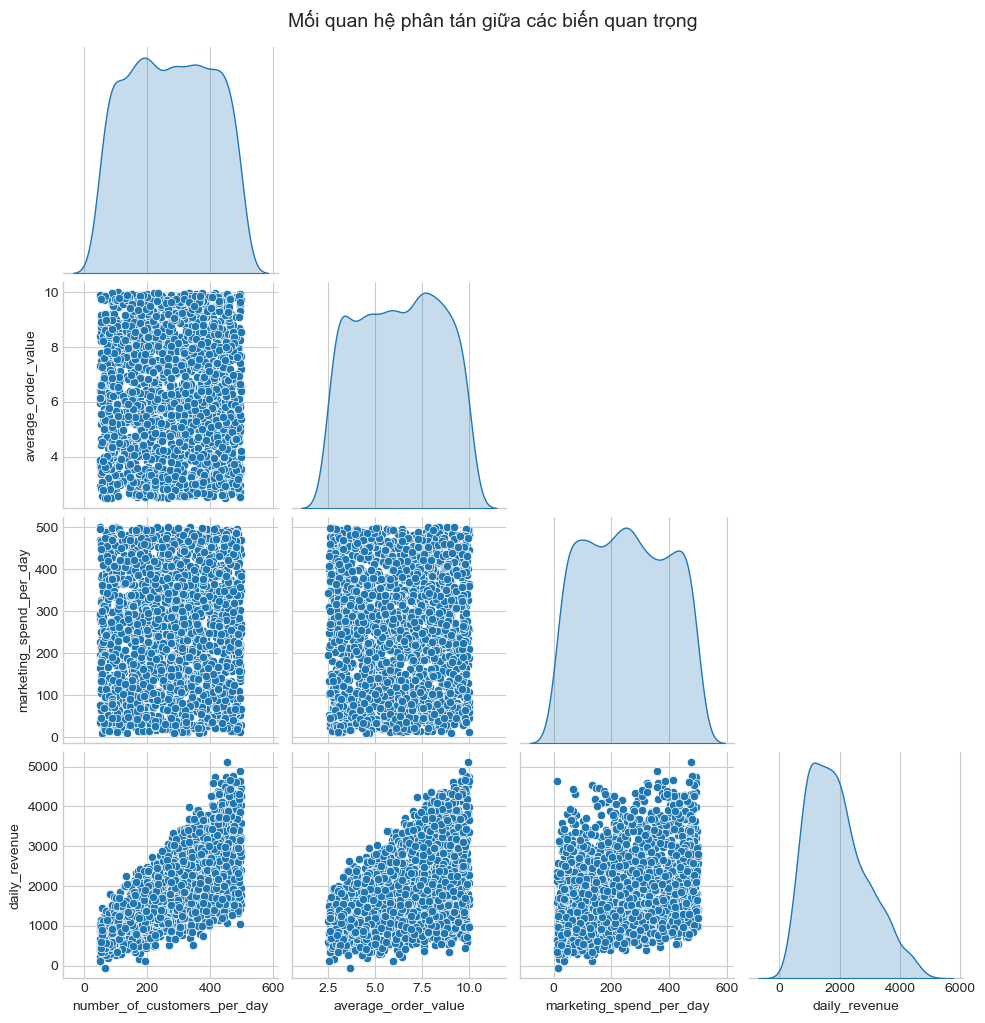

In [15]:
# 3. Pairplot (Xem xét phân tán của một số biến chính)
cols_to_plot = ['number_of_customers_per_day', 'average_order_value', 'marketing_spend_per_day', 'daily_revenue']
sns.pairplot(df[cols_to_plot], diag_kind='kde', corner=True)
plt.suptitle('Mối quan hệ phân tán giữa các biến quan trọng', y=1.02, fontsize=14)
plt.show()

Thông qua các biểu đồ phân tán trong Hình 2:
- Chúng ta thấy được mối quan hệ hai chiều rất khác biệt giữa các yếu tố vận hành và doanh thu quán.
- Đối với number_of_customers_per_day và average_order_value, các điểm dữ liệu liên kết với nhau tạo thành một dải xu hướng dốc lên rõ rệt, cho thấy mối tương quan thuận mang tính ổn định: doanh thu tăng trưởng đều đặn khi số lượng khách hoặc giá trị đơn hàng cải thiện. 
- Trái lại, biến marketing_spend_per_day lại phân tán thành một mảng điểm thiếu trật tự trên biểu đồ, cho thấy rằng chi phí marketing hiện tại không tạo ra một tác động tăng trưởng tuyến tính rõ rệt đối với doanh thu hàng ngày.
- Những quan sát trực quan này đóng vai trò là cơ sở thực tế quan trọng: chúng xác định được các yếu tố đầu vào có sức ảnh hưởng trực tiếp (khách hàng, đơn hàng) và các yếu tố còn mang tính nhiễu (marketing), từ đó giải thích lý do tại sao mô hình hồi quy tuyến tính của nhóm có khả năng dự báo hiệu quả dựa trên lượng khách nhưng lại gặp khó khăn hơn khi phụ thuộc vào dữ liệu chi phí marketing. 

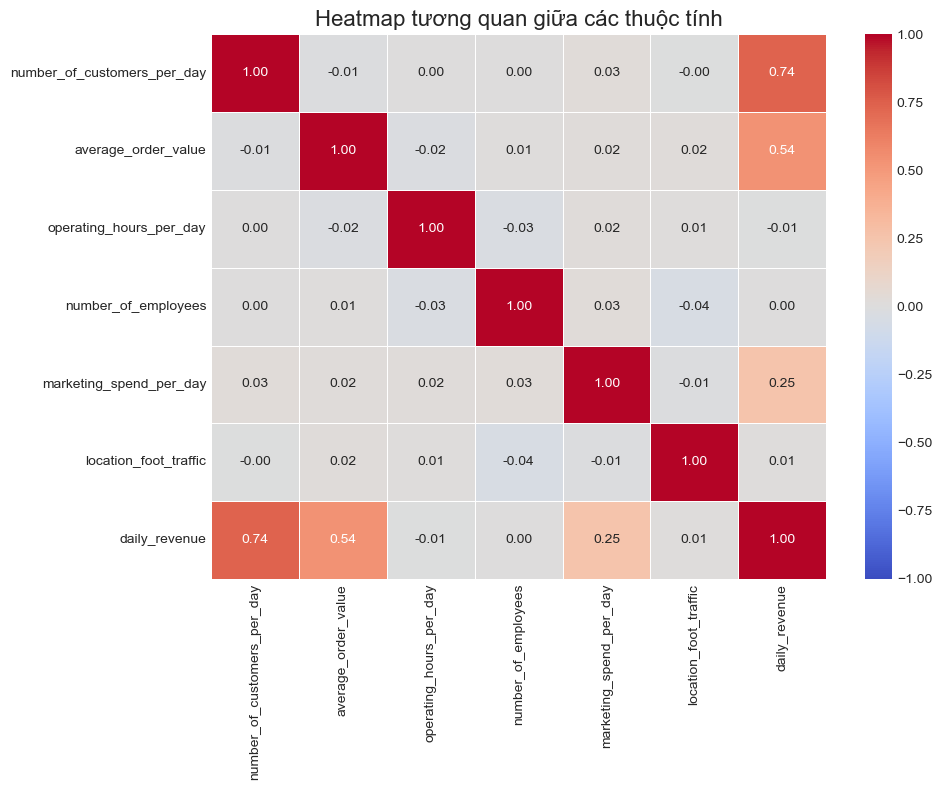

In [16]:
# 4. Heatmap (Ma trận tương quan)
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các thuộc tính', fontsize=16)
plt.tight_layout()
plt.show()

Dựa vào ma trận tương quan tại Hình 3: chúng ta có thể định lượng chính xác mức độ ảnh hưởng của từng yếu tố đến doanh thu (daily_revenue). 
- Biến number_of_customers_per_day cho thấy sức mạnh dự báo cao nhất với hệ số tương quan đạt 0.74 (thể hiện bằng sắc đỏ đậm)
- tiếp theo là average_order_value với mức 0.54. Đây là hai đặc trưng cốt lõi quyết định độ chính xác của mô hình. 
- Ngược lại, các biến như operating_hours_per_day, number_of_employees và location_foot_traffic có hệ số tương quan gần như bằng 0, cho thấy chúng không có tác động tuyến tính đến doanh thu và có thể xem xét loại bỏ để giảm độ phức tạp cho mô hình. 
- Đặc biệt, quan sát khu vực giao nhau giữa các biến đầu vào (không tính cột doanh thu), các hệ số đều dao động ở mức rất thấp (từ -0.04 đến 0.03). Điều này khẳng định bộ dữ liệu không xảy ra hiện tượng đa cộng tuyến (multicollinearity), giúp đảm bảo tính ổn định và độ tin cậy cao cho các hệ số của mô hình Hồi quy tuyến tính. 

In [17]:
print("\n--- MỨC ĐỘ TƯƠNG QUAN VỚI DOANH THU (DAILY_REVENUE) ---")
print(correlation_matrix['daily_revenue'].sort_values(ascending=False))


--- MỨC ĐỘ TƯƠNG QUAN VỚI DOANH THU (DAILY_REVENUE) ---
daily_revenue                  1.000000
number_of_customers_per_day    0.736461
average_order_value            0.535694
marketing_spend_per_day        0.254812
location_foot_traffic          0.013469
number_of_employees            0.003295
operating_hours_per_day       -0.005323
Name: daily_revenue, dtype: float64
